In [ ]:
from pathlib import Path
import os, sys

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)


In [1]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets

In [2]:
# =========================================================
# 1) Reproducibility
# =========================================================
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# =========================================================
# 2) Model
# =========================================================
class AblationMLP(nn.Module):
    def __init__(self, use_dropout=False, use_batchnorm=False, dropout_p=0.2, hidden_sizes=None):
        super(AblationMLP, self).__init__()

        if hidden_sizes is None:
            hidden_sizes = [1024, 512, 256]

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(3072, hidden_sizes[0])
        self.bn1 = nn.BatchNorm1d(hidden_sizes[0]) if use_batchnorm else None
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_p) if use_dropout else None

        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.bn2 = nn.BatchNorm1d(hidden_sizes[1]) if use_batchnorm else None
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_p) if use_dropout else None

        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.bn3 = nn.BatchNorm1d(hidden_sizes[2]) if use_batchnorm else None
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout_p) if use_dropout else None

        self.fc4 = nn.Linear(hidden_sizes[2], 10)

        self.use_dropout = use_dropout
        self.use_batchnorm = use_batchnorm

    def forward(self, x):
        x = self.flatten(x)

        x = self.fc1(x)
        if self.use_batchnorm:
            x = self.bn1(x)
        x = self.relu1(x)
        if self.use_dropout:
            x = self.dropout1(x)

        x = self.fc2(x)
        if self.use_batchnorm:
            x = self.bn2(x)
        x = self.relu2(x)
        if self.use_dropout:
            x = self.dropout2(x)

        x = self.fc3(x)
        if self.use_batchnorm:
            x = self.bn3(x)
        x = self.relu3(x)
        if self.use_dropout:
            x = self.dropout3(x)

        x = self.fc4(x)
        return x

In [4]:
# =========================================================
# 3) Data Transforms
# =========================================================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

In [5]:
# =========================================================
# 4) Load CIFAR-10
# =========================================================
full_train_aug  = datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_transform)
full_train_eval = datasets.CIFAR10(root='./data', train=True,  download=True, transform=eval_transform)
full_test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=eval_transform)

/Users/omar/Documents/uni/DL/project_1/dl_env/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [6]:
# =========================================================
# 5) Split: Train 15k | Val 5k | Test 10k
# =========================================================
generator = torch.Generator().manual_seed(42)
all_indices = torch.randperm(len(full_train_aug), generator=generator).tolist()

train_indices = all_indices[:15000]
val_indices   = all_indices[15000:20000]

train_dataset = torch.utils.data.Subset(full_train_aug,  train_indices)
val_dataset   = torch.utils.data.Subset(full_train_eval, val_indices)
test_dataset  = full_test_dataset

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print("=" * 80)
print("DATA PARTITIONING")
print("=" * 80)
print(f"Training set size:   {len(train_dataset):,} images")
print(f"Validation set size: {len(val_dataset):,} images")
print(f"Test set size:       {len(test_dataset):,} images")
print("=" * 80)

DATA PARTITIONING
Training set size:   15,000 images
Validation set size: 5,000 images
Test set size:       10,000 images


In [ ]:
# =========================================================
# 6) Hyperparameters  *** OPTIMIZED ***
# =========================================================
learning_rate = 1e-3        
max_epochs    = 50
dropout_p     = 0.2         

l1_lambda      = 5e-7       
l2_weight_decay = 1e-4

use_adversarial_training = True
adv_ratio = 0.15            
epsilon   = 0.03

use_early_stopping = True
patience  = 10              
min_delta = 0.001

In [ ]:
# =========================================================
# 7) Model / Optimizer / Loss / Scheduler
# =========================================================
model = AblationMLP(
    use_dropout=True,
    use_batchnorm=True,
    dropout_p=dropout_p,
    hidden_sizes=[1024, 512, 256]
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=l2_weight_decay)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=1e-5)

loss_fn = nn.CrossEntropyLoss()

print(f"Device:              {device}")
print(f"Optimizer:           AdamW")
print(f"Learning Rate:       {learning_rate}")
print(f"Max Epochs:          {max_epochs}")
print(f"Dropout:             {dropout_p}")
print(f"L1 Lambda:           {l1_lambda}")
print(f"L2 Weight Decay:     {l2_weight_decay}")
print(f"Adversarial Ratio:   {adv_ratio}")
print(f"Epsilon:             {epsilon}")
print(f"Early Stop Patience: {patience}")
print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")

Device:              cpu
Optimizer:           AdamW
Learning Rate:       0.001
Max Epochs:          50
Dropout:             0.2
L1 Lambda:           5e-07
L2 Weight Decay:     0.0001
Adversarial Ratio:   0.15
Epsilon:             0.03
Early Stop Patience: 10
Total parameters:    3,809,034


In [9]:
# =========================================================
# 8) Helper Functions
# =========================================================
def evaluate(model, dataloader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
    model.train()
    return 100 * correct / total


def compute_loss(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            total_loss += loss_fn(outputs, labels).item()
    model.train()
    return total_loss / len(dataloader)


def compute_l1_penalty(model):
    l1_penalty = 0.0
    for param in model.parameters():
        l1_penalty += torch.sum(torch.abs(param))
    return l1_penalty


def fgsm_attack(model, images, labels, epsilon, loss_fn):
    images_adv = images.clone().detach().requires_grad_(True)
    outputs = model(images_adv)
    loss = loss_fn(outputs, labels)
    model.zero_grad()
    loss.backward()
    adv_images = images_adv + epsilon * images_adv.grad.sign()
    adv_images = torch.clamp(adv_images, -3.0, 3.0)
    return adv_images.detach()


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_val_loss = float("inf")
        self.counter    = 0
        self.best_state = None
        self.stop       = False

    def step(self, val_loss, model):
        if val_loss < self.best_val_loss - self.min_delta:
            self.best_val_loss = val_loss
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def train_epoch(model, train_loader, optimizer, loss_fn, device,
                l1_lambda=0.0, use_adv=False, adv_ratio=0.0, epsilon=0.03):
    model.train()
    total_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        if use_adv and np.random.rand() < adv_ratio:
            adv_images = fgsm_attack(model, images, labels, epsilon, loss_fn)
            outputs = model(adv_images)
        else:
            outputs = model(images)

        ce_loss = loss_fn(outputs, labels)
        l1_penalty = compute_l1_penalty(model)
        loss = ce_loss + l1_lambda * l1_penalty

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(train_loader)

In [ ]:
# =========================================================
# 9) Training Loop
# =========================================================
train_losses, val_losses, test_losses = [], [], []
train_accuracies, val_accuracies, test_accuracies = [], [], []

early_stopper = EarlyStopping(patience=patience, min_delta=min_delta)

for epoch in range(max_epochs):
    train_loss = train_epoch(
        model, train_loader, optimizer, loss_fn, device,
        l1_lambda=l1_lambda,
        use_adv=use_adversarial_training,
        adv_ratio=adv_ratio,
        epsilon=epsilon
    )

    scheduler.step()

    train_acc = evaluate(model, train_loader, device)
    val_loss  = compute_loss(model, val_loader, loss_fn, device)
    val_acc   = evaluate(model, val_loader, device)
    test_loss = compute_loss(model, test_loader, loss_fn, device)
    test_acc  = evaluate(model, test_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(
        f"Epoch {epoch+1:2d}/{max_epochs} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Test Loss: {test_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Test Acc: {test_acc:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

    if use_early_stopping:
        early_stopper.step(val_loss, model)
        if early_stopper.stop:
            print(f"\nEarly stopping triggered at epoch {epoch+1}.")
            break

# Restore best model
if use_early_stopping and early_stopper.best_state is not None:
    model.load_state_dict(early_stopper.best_state)
    print("Best model restored.")

/Users/omar/Documents/uni/DL/project_1/dl_env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch  1/50 | Train Loss: 1.9986 | Val Loss: 1.7839 | Test Loss: 1.7580 | Train Acc: 33.27% | Val Acc: 34.38% | Test Acc: 35.01% | LR: 0.000999
Epoch  2/50 | Train Loss: 1.8545 | Val Loss: 1.7341 | Test Loss: 1.6976 | Train Acc: 36.03% | Val Acc: 36.52% | Test Acc: 38.49% | LR: 0.000996
Epoch  3/50 | Train Loss: 1.7910 | Val Loss: 1.6642 | Test Loss: 1.6212 | Train Acc: 39.38% | Val Acc: 40.16% | Test Acc: 41.54% | LR: 0.000991
Epoch  4/50 | Train Loss: 1.7618 | Val Loss: 1.6460 | Test Loss: 1.5940 | Train Acc: 39.88% | Val Acc: 40.78% | Test Acc: 42.01% | LR: 0.000984
Epoch  5/50 | Train Loss: 1.7201 | Val Loss: 1.5567 | Test Loss: 1.5168 | Train Acc: 43.37% | Val Acc: 43.60% | Test Acc: 45.18% | LR: 0.000976
Epoch  6/50 | Train Loss: 1.7009 | Val Loss: 1.5606 | Test Loss: 1.5233 | Train Acc: 42.94% | Val Acc: 42.92% | Test Acc: 45.04% | LR: 0.000965
Epoch  7/50 | Train Loss: 1.6620 | Val Loss: 1.5391 | Test Loss: 1.5022 | Train Acc: 44.32% | Val Acc: 44.78% | Test Acc: 45.16% | LR: 0

In [11]:
# =========================================================
# 10) Final Evaluation
# =========================================================
print("\n" + "=" * 80)
print("FINAL TEST EVALUATION (BEST CHECKPOINT)")
print("=" * 80)

final_train_acc  = evaluate(model, train_loader, device)
final_val_acc    = evaluate(model, val_loader,   device)
final_test_acc   = evaluate(model, test_loader,  device)

final_train_loss = compute_loss(model, train_loader, loss_fn, device)
final_val_loss   = compute_loss(model, val_loader,   loss_fn, device)
final_test_loss  = compute_loss(model, test_loader,  loss_fn, device)

print(f"Training Accuracy:   {final_train_acc:.2f}%")
print(f"Validation Accuracy: {final_val_acc:.2f}%")
print(f"Test Accuracy:       {final_test_acc:.2f}%")
print(f"\nTraining Loss:       {final_train_loss:.4f}")
print(f"Validation Loss:     {final_val_loss:.4f}")
print(f"Test Loss:           {final_test_loss:.4f}")
print(f"\nGeneralization Gap:")
print(f"  Train - Val:  {final_train_acc - final_val_acc:.2f}%")
print(f"  Train - Test: {final_train_acc - final_test_acc:.2f}%")


FINAL TEST EVALUATION (BEST CHECKPOINT)
Training Accuracy:   58.73%
Validation Accuracy: 54.92%
Test Accuracy:       55.78%

Training Loss:       1.1538
Validation Loss:     1.2728
Test Loss:           1.2370

Generalization Gap:
  Train - Val:  3.81%
  Train - Test: 2.95%


In [12]:
# =========================================================
# 11) Adversarial Evaluation
# =========================================================
def evaluate_adversarial(model, dataloader, device, epsilon=0.03):
    model.eval()
    correct, total = 0, 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        adv_images = fgsm_attack(model, images, labels, epsilon, loss_fn)
        with torch.no_grad():
            outputs = model(adv_images)
            _, predicted = torch.max(outputs.data, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()
    model.train()
    return 100 * correct / total

adv_test_acc = evaluate_adversarial(model, test_loader, device, epsilon=epsilon)
print(f"\nAdversarial Test Accuracy (epsilon={epsilon}): {adv_test_acc:.2f}%")
print(f"Robustness Drop (Clean - Adv): {final_test_acc - adv_test_acc:.2f}%")
print("=" * 80)


Adversarial Test Accuracy (epsilon=0.03): 43.83%
Robustness Drop (Clean - Adv): 11.95%


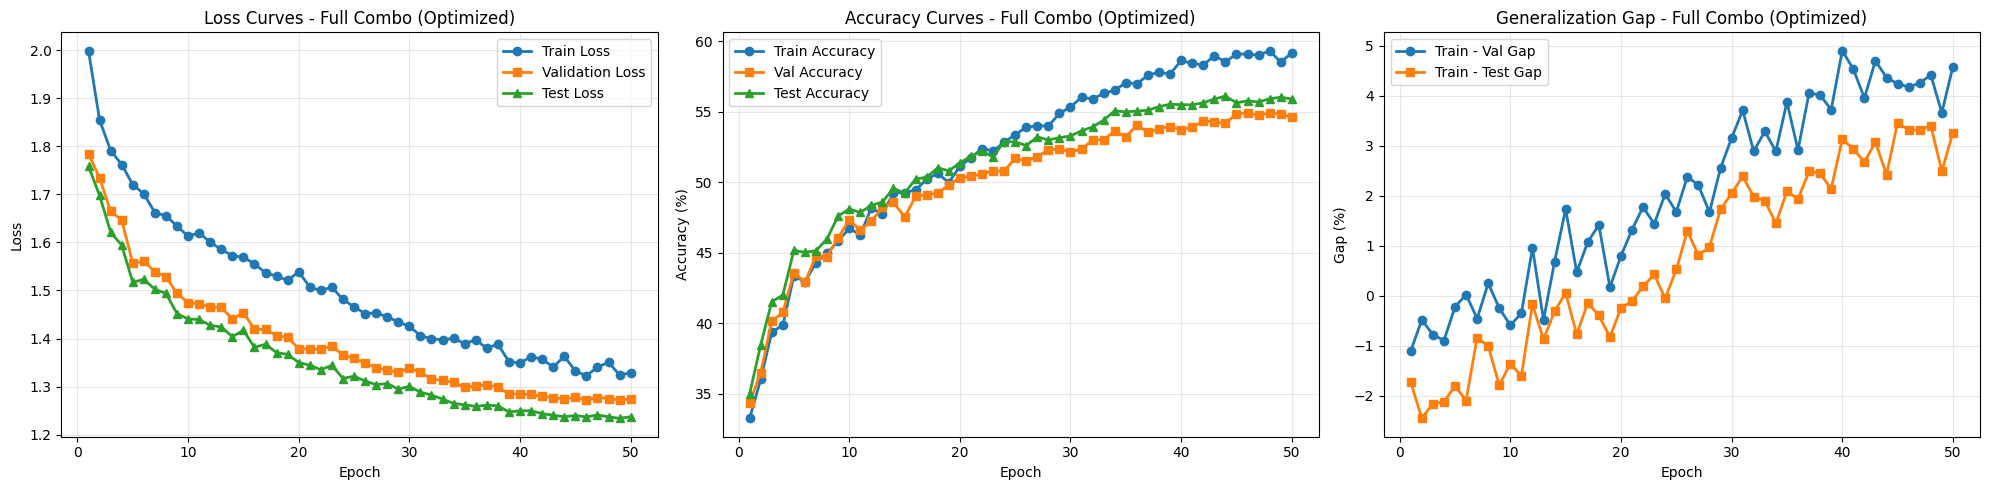

In [13]:
# =========================================================
# 12) Plot Curves
# =========================================================
num_epochs   = len(train_losses)
epochs_range = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(epochs_range, train_losses, 'o-', label='Train Loss',      linewidth=2)
axes[0].plot(epochs_range, val_losses,   's-', label='Validation Loss',  linewidth=2)
axes[0].plot(epochs_range, test_losses,  '^-', label='Test Loss',        linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves - Full Combo (Optimized)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, train_accuracies, 'o-', label='Train Accuracy', linewidth=2)
axes[1].plot(epochs_range, val_accuracies,   's-', label='Val Accuracy',   linewidth=2)
axes[1].plot(epochs_range, test_accuracies,  '^-', label='Test Accuracy',  linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Curves - Full Combo (Optimized)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

train_val_gap  = np.array(train_accuracies) - np.array(val_accuracies)
train_test_gap = np.array(train_accuracies) - np.array(test_accuracies)
axes[2].plot(epochs_range, train_val_gap,  'o-', label='Train - Val Gap',  linewidth=2)
axes[2].plot(epochs_range, train_test_gap, 's-', label='Train - Test Gap', linewidth=2)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Gap (%)')
axes[2].set_title('Generalization Gap - Full Combo (Optimized)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('full_combo_optimized_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# =========================================================
# 13) Final Summary
# =========================================================
print("\n" + "=" * 80)
print("FULL COMBO SUMMARY (AFTER OPTIMIZATION)")
print("=" * 80)
print("Techniques used together:")
print("  - L1 Regularization      (lambda=5e-7)")
print("  - L2 Regularization      (weight_decay=1e-4)")
print("  - Dropout                (p=0.2)  ← reduced from 0.5")
print("  - Batch Normalization")
print("  - Data Augmentation")
print("  - Adversarial Training   (ratio=0.15) ← reduced from 0.30")
print("  - Early Stopping         (patience=10)")
print("  - AdamW Optimizer        ← upgraded from SGD")
print("  - CosineAnnealingLR      ← added scheduler")
print(f"\nFinal Train Accuracy:   {final_train_acc:.2f}%")
print(f"Final Val Accuracy:     {final_val_acc:.2f}%")
print(f"Final Test Accuracy:    {final_test_acc:.2f}%")
print(f"Adversarial Test Acc:   {adv_test_acc:.2f}%")
print(f"Train-Val Gap:          {final_train_acc - final_val_acc:.2f}%")
print(f"Train-Test Gap:         {final_train_acc - final_test_acc:.2f}%")
print("=" * 80)


FULL COMBO SUMMARY (AFTER OPTIMIZATION)
Techniques used together:
  - L1 Regularization      (lambda=5e-7)
  - L2 Regularization      (weight_decay=1e-4)
  - Dropout                (p=0.2)  ← reduced from 0.5
  - Batch Normalization
  - Data Augmentation
  - Adversarial Training   (ratio=0.15) ← reduced from 0.30
  - Early Stopping         (patience=10)
  - AdamW Optimizer        ← upgraded from SGD
  - CosineAnnealingLR      ← added scheduler

Final Train Accuracy:   58.73%
Final Val Accuracy:     54.92%
Final Test Accuracy:    55.78%
Adversarial Test Acc:   43.83%
Train-Val Gap:          3.81%
Train-Test Gap:         2.95%
